# Tutorial 8: Colocalization Analysis (2-way & 3-way)

## Objective

Beyond pairwise distance matrices (Tutorial 7), chromatin tracing data allows us to ask:
*given a specific genomic locus (anchor), which other loci are physically close to it?*

This tutorial covers two complementary analyses:

1. **2-way colocalization** (`plot_4m`) — For a given anchor barcode, compute the frequency
   at which each other barcode is within a distance cutoff. Produces a 1D profile (4M plot).
2. **3-way colocalization** (`trace_3way_coloc`) — For a given anchor barcode, compute the
   frequency at which **pairs** of other barcodes are *both* within the distance cutoff
   simultaneously. Produces a 2D heatmap.

Both scripts include **bootstrapping** to estimate statistical confidence (mean ± SEM).

## Scientific context

- **2-way (4M)**: reveals which loci interact with a chosen viewpoint — analogous to 4C/Capture-C.
- **3-way**: identifies higher-order contacts where 3 loci converge simultaneously — evidence for
  transcription factories, chromatin hubs, or phase-separated condensates.

## Input

We use the Pdx1-positive trace file from Tutorial 6:

| File | Description |
|------|-------------|
| `Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Pdx1.ecsv` | Traces inside the Pdx1 mask |

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

data_path = "/home/devos/Documents/data_to_compare_pdx1/PDX1"
input_trace = f"{data_path}/merged_traces_split.ecsv"

print(f"Input trace: {input_trace}")

Input trace: /home/devos/Documents/data_to_compare_pdx1/PDX1/merged_traces_split.ecsv


## Step 1: 2-way colocalization with `plot_4m`

`plot_4m` computes, for a chosen **anchor** barcode, how frequently every other barcode is found
within a distance cutoff. This is repeated over bootstrap iterations to obtain mean ± SEM.

The result is a **4M plot**: a 1D profile where the X-axis is the barcode number and the
Y-axis is the colocalization frequency with the anchor.

### Parameters

| Option | Default | Description |
|--------|---------|-------------|
| `--input` | — | Input trace file (ECSV) |
| `--anchors` | — | One or more anchor barcode numbers (space-separated) |
| `--cutoff` | `0.2` | Distance threshold in µm |
| `--bootstrapping_cycles` | `10` | Number of bootstrap iterations |
| `--output` | `colocalization_plot.png` | Base name for output plots |
| `--x_min` / `--x_max` | auto | X-axis range for the plot |

In [2]:
# 2-way colocalization: anchor at barcode 10, distance cutoff 0.25 µm
!plot_4m --input {input_trace} --anchors 10 --cutoff 0.25 --bootstrapping_cycles 50 --output {data_path}/coloc_4m.png


$ Processing trace file: /home/devos/Documents/data_to_compare_pdx1/PDX1/merged_traces_split.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/devos/Documents/data_to_compare_pdx1/PDX1/merged_traces_split.ecsv

$ Processing anchors: [10]


The output is saved as `coloc_4m_anchor_10.png` (the anchor ID is appended automatically).

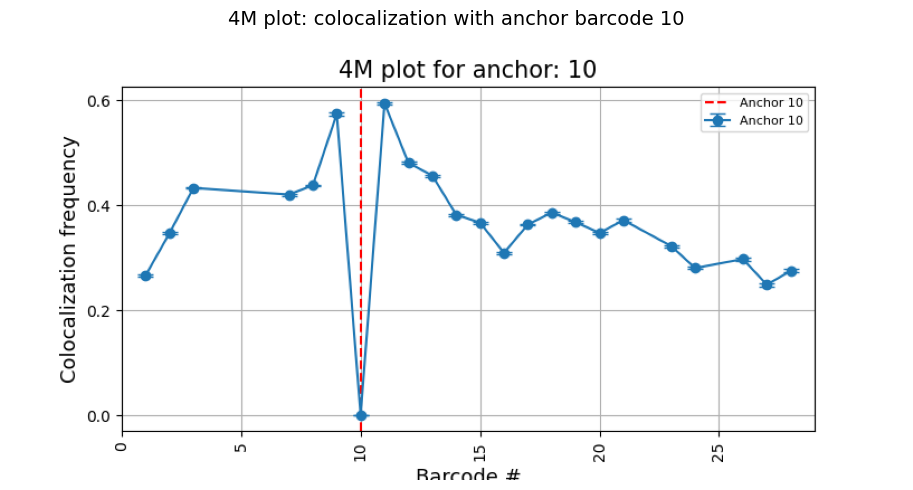

In [3]:
plot_file = f"{data_path}/coloc_4m_anchor_10.png"

img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(img)
ax.axis('off')
ax.set_title("4M plot: colocalization with anchor barcode 10", fontsize=14)
plt.tight_layout()
plt.show()

**How to read the 4M plot:**
- Each point is a barcode; the Y-value is the fraction of traces where that barcode is within 0.25 µm of the anchor.
- Error bars show the bootstrap SEM.
- The **red dashed line** marks the anchor barcode itself.
- Barcodes **near the anchor** on the genome (close barcode numbers) are expected to have higher frequencies.
- A barcode **far on the genome** but with high frequency suggests a **long-range contact**.

### Multiple anchors

You can compute 4M profiles for several anchors in a single run.
Each anchor produces its own plot.

In [4]:
# Multiple anchors in one run
!plot_4m --input {input_trace} --anchors 3 10 20 --cutoff 0.25 --bootstrapping_cycles 50 --output {data_path}/coloc_4m_multi.png


$ Processing trace file: /home/devos/Documents/data_to_compare_pdx1/PDX1/merged_traces_split.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/devos/Documents/data_to_compare_pdx1/PDX1/merged_traces_split.ecsv

$ Processing anchors: [3, 10, 20]


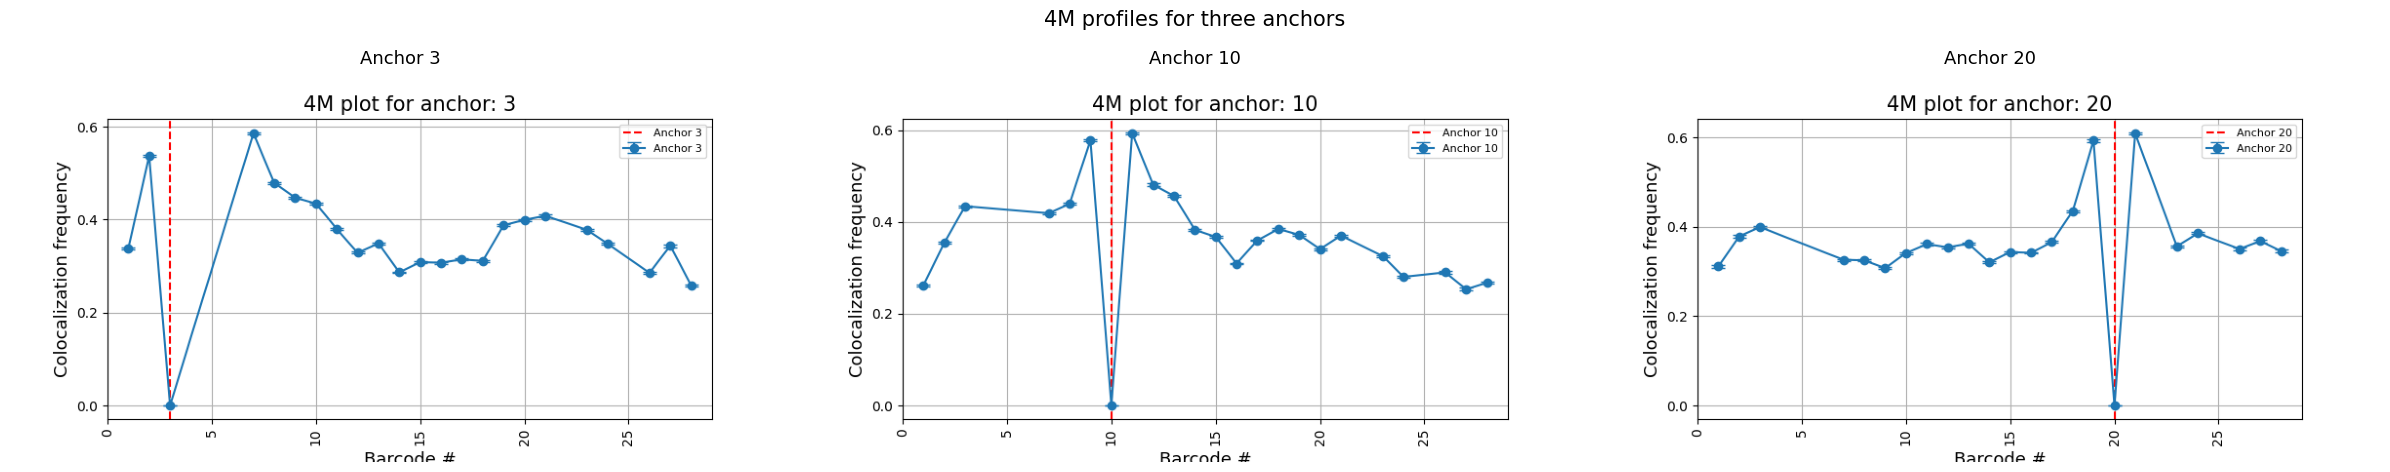

In [5]:
# Display all anchor plots side by side
anchors = [3, 10, 20]
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

for ax, anchor in zip(axes, anchors):
    plot_file = f"{data_path}/coloc_4m_multi_anchor_{anchor}.png"
    img = mpimg.imread(plot_file)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Anchor {anchor}", fontsize=13)

fig.suptitle("4M profiles for three anchors", fontsize=15)
plt.tight_layout()
plt.show()

## Step 2: 3-way colocalization with `trace_3way_coloc`

`trace_3way_coloc` extends the analysis to **three-body contacts**.
Given an anchor barcode, it checks every pair of other barcodes (i, j) and asks:
*in what fraction of traces are anchor, i, and j all within the distance cutoff simultaneously?*

The result is a **symmetric heatmap** where each cell (i, j) shows the 3-way
colocalization frequency. A second heatmap shows the bootstrap SEM.

### Parameters

| Option | Default | Description |
|--------|---------|-------------|
| `--input` | — | Input trace file (ECSV) |
| `--anchors` | — | One or more anchor barcode numbers |
| `--cutoff` | `0.2` | Distance threshold in µm |
| `--bootstrapping_cycles` | `10` | Number of bootstrap iterations |
| `--output` | `threeway_coloc_plot.png` | Base name for output files |
| `--vmin` / `--vmax` | auto | Colormap range |

In [6]:
# 3-way colocalization: anchor at barcode 10
!trace_3way_coloc --input {input_trace} --anchors 10 --cutoff 0.25 --bootstrapping_cycles 50 --output {data_path}/coloc_3way.png

>> Processing file: /home/devos/Documents/data_to_compare_pdx1/PDX1/merged_traces_split.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/devos/Documents/data_to_compare_pdx1/PDX1/merged_traces_split.ecsv
Using distance cutoff: 0.25 µm
Performing 50 bootstrap iterations

Running analysis for anchor: 10
Saved three-way co-localization heatmap to: /home/devos/Documents/data_to_compare_pdx1/PDX1/coloc_3way_merged_traces_split_anchor_10
Saved SEM heatmap to: /home/devos/Documents/data_to_compare_pdx1/PDX1/coloc_3way_merged_traces_split_anchor_10_sem.png


This produces:

| Output file | Description |
|-------------|-------------|
| `coloc_3way_<trace_basename>_anchor_10.png` | 3-way frequency heatmap |
| `coloc_3way_<trace_basename>_anchor_10.npy` | Frequency matrix (NumPy) |
| `coloc_3way_<trace_basename>_anchor_10_sem.png` | Bootstrap SEM heatmap |

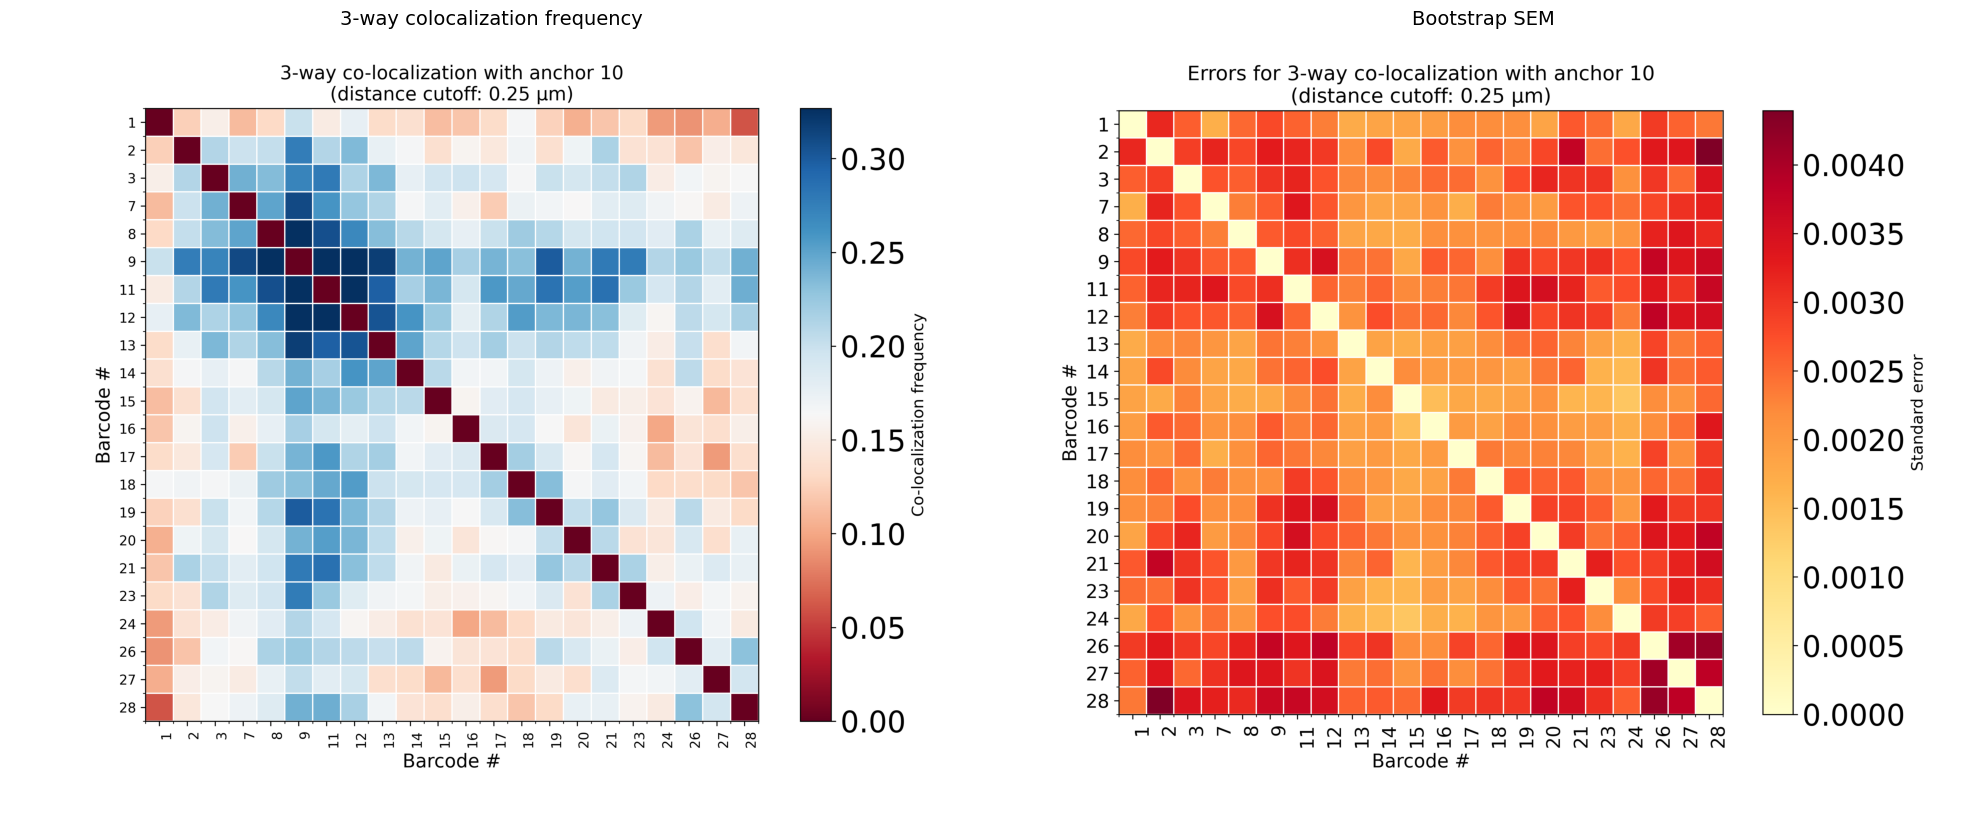

In [7]:
# Find and display the 3-way heatmap (frequency and SEM)
freq_matches = sorted(glob.glob(f"{data_path}/coloc_3way_*_anchor_10.png"))
sem_matches = sorted(glob.glob(f"{data_path}/coloc_3way_*_anchor_10_sem.png"))

if freq_matches and sem_matches:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    img_freq = mpimg.imread(freq_matches[0])
    axes[0].imshow(img_freq)
    axes[0].axis('off')
    axes[0].set_title("3-way colocalization frequency", fontsize=14)

    img_sem = mpimg.imread(sem_matches[0])
    axes[1].imshow(img_sem)
    axes[1].axis('off')
    axes[1].set_title("Bootstrap SEM", fontsize=14)

    plt.tight_layout()
    plt.show()

**How to read the 3-way heatmap:**
- Axes show barcode IDs (excluding the anchor).
- Cell (i, j) = fraction of traces where anchor, barcode i, and barcode j are **all three** within the distance cutoff.
- **Black crosshair** marks the anchor barcode position.
- High values off the diagonal reveal **three-body hubs** where three distant loci converge.
- The SEM heatmap helps identify which entries are statistically robust (low SEM).

## Step 3: Varying the distance cutoff

The distance cutoff has a strong effect on colocalization frequencies.
A small cutoff (e.g. 0.15 µm) captures only very tight contacts, while a larger one (e.g. 0.35 µm)
includes more diffuse proximity. Try different values to see how the patterns change:

```bash
# Tight cutoff
plot_4m --input Trace.ecsv --anchors 10 --cutoff 0.15 --output coloc_tight.png

# Relaxed cutoff
plot_4m --input Trace.ecsv --anchors 10 --cutoff 0.35 --output coloc_relaxed.png
```

A robust interaction should be visible across a range of cutoffs.

## Summary

### Workflow

```
trace file (.ecsv)
       │
       ├─── plot_4m               →  1D profile (anchor vs each barcode)
       │
       └─── trace_3way_coloc      →  2D heatmap (anchor vs pairs) + SEM
```

### Commands reference

```bash
# 2-way (4M profile)
plot_4m --input Trace.ecsv --anchors 10 --cutoff 0.25 --bootstrapping_cycles 50 --output 4m.png

# 3-way (heatmap)
trace_3way_coloc --input Trace.ecsv --anchors 10 --cutoff 0.25 --bootstrapping_cycles 50 --output 3way.png
```

### Key differences

| | `plot_4m` (2-way) | `trace_3way_coloc` (3-way) |
|---|---|---|
| Question | Is barcode X close to anchor? | Are barcodes X **and** Y both close to anchor? |
| Output | 1D line plot | 2D symmetric heatmap |
| Complexity | O(n) per trace | O(n²) per trace |
| Detects | Pairwise interactions | Higher-order hubs |

### Notes

- **Bootstrap cycles**: 10 is fast for exploration; use 100–1000 for publication.
- **Multiple anchors**: both scripts accept `--anchors 3 10 20` to process several viewpoints in one run.
- **Large datasets**: 3-way analysis is computationally heavier than 2-way. For many barcodes, consider running on a filtered/split subset.

**Next:** [Tutorial 9 — Compare datasets](tutorial_09_compare_datasets.ipynb)